# 5단계 — 혼잡 예측 모델 (분류)

**목표:** 1시간 후 혼잡 발생 여부를 예측한다.

**입력:** `data/processed/hourly_panel_final.parquet` (4단계 산출물)
**출력:** 학습된 모델 + 성능 비교표

---

## 이 단계의 설계 원칙 — 이전 프로젝트의 실패를 갚는다

| 이전 프로젝트(1탄)의 문제 | 이번 단계의 처리 |
|---|---|
| t 예측에 t−1의 **실제값**을 입력으로 사용 → R² 0.99로 부풀려짐 | **예측 시점까지의 정보만** 사용, 시점 분리 엄수 |
| R² 단독 평가 → 지표 왜곡을 놓침 | **정밀도·재현율·F1·PR-AUC** 중심 평가 |
| 비교 기준 없음 → "잘한 것"인지 알 수 없음 | **persistence 베이스라인 대비 개선률**을 주 성과 지표로 |
| 무작위 분할 | **시간 순서 기반 분할** |

### 회귀에서 분류로 전환한 이유

- **1탄:** "1시간 뒤 교통량이 몇 대인가" → 회귀 → R²가 분산에 좌우되어 해석이 꼬였다
- **이번:** "1시간 뒤 막힐 것인가" → **분류** → 실무 언어와 일치하고 평가가 명확하다

## 셀 1 — 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 250)

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = BASE / 'data' / 'processed'

df = pd.read_parquet(PROC / 'hourly_panel_final.parquet')

# 세그먼트 식별자 (교차로+접근로+이동류)
df['세그'] = df.교차로.astype(str) + '|' + df.접근로.astype(str) + '|' + df.이동류.astype(str)
df = df.sort_values(['세그', 'CollectedDate']).reset_index(drop=True)

print('로드 완료:', df.shape)
print('세그먼트 수:', df.세그.nunique())
print(f'전체 혼잡률: {100*df.혼잡.mean():.2f}%')

로드 완료: (411821, 22)
세그먼트 수: 30
전체 혼잡률: 5.36%


---
## 1. 시계열 연속성 확인

시차(lag) 변수를 만들기 전에, **직전 관측이 정말 1시간 전인지** 확인해야 한다.
센서 결측으로 시간이 건너뛰면 잘못된 값이 lag로 들어간다.

In [2]:
g = df.groupby('세그')
df['간격'] = g.CollectedDate.diff().dt.total_seconds() / 3600

print(f'직전 관측이 정확히 1시간 전인 비율: {100*(df.간격==1).mean():.1f}%')
print('\n간격 분포 (상위 5):')
print(df.간격.value_counts().head(5).to_string())

직전 관측이 정확히 1시간 전인 비율: 98.6%

간격 분포 (상위 5):
간격
1.0    406136
2.0      2619
3.0       933
4.0       467
5.0       304


> 98.6%가 정확히 1시간 간격이다. 나머지는 결측 구간 전후이므로,
> **타깃과 lag 생성 시 간격이 1시간이 아닌 경우를 제외**한다.

---
## 2. 피처 생성 — 데이터 누수를 원천 차단

> **데이터 누수(data leakage)란?**
> 예측 시점에 알 수 없는 정보를 모델에 넣어, 실제보다 성능이 좋게 나오는 현상.
> 시험 볼 때 답안지를 미리 본 것과 같아서, 연습에선 만점이지만 실전에선 무너진다.

**규칙: t+1을 예측할 때 t 시점까지의 정보만 사용한다.**

In [3]:
# ── 과거 및 현재 정보만 사용 ──
for lag in [1, 2, 3]:
    df[f'혼잡지수_lag{lag}'] = g.혼잡지수.shift(lag)
    df[f'속도_lag{lag}']     = g.속도.shift(lag)

df['혼잡지수_현재'] = df.혼잡지수          # t 시점 = 예측 시점, 사용 가능
df['속도_현재']     = df.속도
df['교통량_현재']   = df.교통량
df['혼잡_현재']     = df.혼잡.astype(int)
df['혼잡지수_변화'] = df.혼잡지수 - df.혼잡지수_lag1

# 이동평균: shift(1) 먼저 → 현재 값이 자기 평균에 포함되지 않게
df['이동평균3'] = g.혼잡지수.transform(lambda s: s.shift(1).rolling(3).mean())

# 동일 시간대의 과거 평균 (expanding = 그 시점까지 누적, 미래 미사용)
df['동시간대평균'] = (df.groupby(['세그','시'], observed=True).혼잡지수
                       .transform(lambda s: s.shift(1).expanding().mean()))

df['평일i'] = df.평일.astype(int)

print('피처 생성 완료')
print('사용 원칙: 모든 피처가 예측 시점(t) 이전 또는 당시 정보만 참조')

피처 생성 완료
사용 원칙: 모든 피처가 예측 시점(t) 이전 또는 당시 정보만 참조


In [4]:
# ── 타깃: 1시간 후 혼잡 여부 ──
df['타깃']   = g.혼잡.shift(-1)
nxt = g.CollectedDate.shift(-1)

# 다음 관측이 정확히 1시간 후가 아니면 타깃 무효화 (결측 구간 건너뛰기 방지)
gap = (nxt - df.CollectedDate).dt.total_seconds() / 3600
df.loc[gap != 1, '타깃'] = np.nan

print(f'타깃 생성 가능: {100*df.타깃.notna().mean():.1f}%')
print(f'타깃 양성률(1시간 후 혼잡): {100*df.타깃.mean():.2f}%')

타깃 생성 가능: 98.6%
타깃 양성률(1시간 후 혼잡): 5.32%


---
## 3. 학습·검증 분할 — 반드시 시간 순서로

> **왜 무작위 분할이 안 되는가?**
> 시계열을 무작위로 섞으면 **미래 데이터로 학습해 과거를 맞히는** 셈이 된다.
> 실제 운영에서는 불가능한 상황이므로 성능이 과대평가된다.

4단계에서 확인한 **동막교 결측 구간(2024.10~2025.02)** 을 피해,
검증 기간을 2025년 4월 이후로 설정한다.

In [5]:
FEATS = ['혼잡지수_현재','속도_현재','교통량_현재','혼잡_현재',
         '혼잡지수_lag1','혼잡지수_lag2','혼잡지수_lag3',
         '속도_lag1','속도_lag2','혼잡지수_변화','이동평균3','동시간대평균',
         '시','요일','평일i','대형차비율','자유속도']

d = df.dropna(subset=['타깃'] + FEATS).copy()
d['타깃'] = d.타깃.astype(int)

CUT = pd.Timestamp('2025-04-01')
train = d[d.CollectedDate <  CUT]
test  = d[d.CollectedDate >= CUT]

print(f'학습: {len(train):,}행  ({train.CollectedDate.min().date()} ~ {train.CollectedDate.max().date()})  혼잡률 {100*train.타깃.mean():.2f}%')
print(f'검증: {len(test):,}행  ({test.CollectedDate.min().date()} ~ {test.CollectedDate.max().date()})  혼잡률 {100*test.타깃.mean():.2f}%')

X_train, y_train = train[FEATS], train.타깃
X_test,  y_test  = test[FEATS],  test.타깃

학습: 301,204행  (2023-11-08 ~ 2025-03-31)  혼잡률 5.24%
검증: 104,229행  (2025-04-01 ~ 2025-09-04)  혼잡률 5.55%


---
## 4. 베이스라인 먼저 — "잘한 것"의 기준을 세운다

> **베이스라인(baseline)이란?**
> 아주 단순한 방법으로 낸 성적. 복잡한 모델은 **이보다 나아야** 의미가 있다.

여기서는 **persistence**(1시간 후에도 지금과 같을 것이라고 예측)를 쓴다.
교통 상황은 관성이 크기 때문에 이 단순한 방법도 상당히 잘 맞는다.

In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, average_precision_score, confusion_matrix,
                             precision_recall_curve)

pred_base = test.혼잡_현재.values

print('=== persistence 베이스라인 ===')
print(f'정확도: {accuracy_score(y_test, pred_base):.4f}')
print(f'정밀도: {precision_score(y_test, pred_base):.4f}')
print(f'재현율: {recall_score(y_test, pred_base):.4f}')
print(f'F1    : {f1_score(y_test, pred_base):.4f}')

print(f'\n【정확도의 함정】')
print(f"  검증셋 혼잡 비율: {100*y_test.mean():.2f}%")
print(f"  '항상 정상'이라고만 답해도 정확도: {100*(1-y_test.mean()):.2f}%")
print('  → 정확도는 이 문제에서 성능 지표로 쓸 수 없다.')

=== persistence 베이스라인 ===
정확도: 0.9679
정밀도: 0.7110
재현율: 0.7096
F1    : 0.7103

【정확도의 함정】
  검증셋 혼잡 비율: 5.55%
  '항상 정상'이라고만 답해도 정확도: 94.45%
  → 정확도는 이 문제에서 성능 지표로 쓸 수 없다.


> **핵심:** 아무 예측도 안 하고 "항상 정상"만 외쳐도 정확도가 94.5%다.
> 그래서 **정밀도와 재현율**을 봐야 한다.
>
> - **정밀도(Precision):** 혼잡이라 예측한 것 중 실제 혼잡 비율 → *헛경보가 적은가*
> - **재현율(Recall):** 실제 혼잡 중 잡아낸 비율 → *놓친 혼잡이 적은가*

---
## 5. 모델 비교 — 데이터가 결정하게 한다

모델을 미리 정하지 않고, 후보를 **같은 조건에서** 비교한다.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

results = []
probas  = {}

def evaluate(name, y_true, y_pred, y_prob=None):
    results.append({
        '모델': name,
        '정확도': round(accuracy_score(y_true, y_pred), 4),
        '정밀도': round(precision_score(y_true, y_pred), 4),
        '재현율': round(recall_score(y_true, y_pred), 4),
        'F1': round(f1_score(y_true, y_pred), 4),
        'PR-AUC': round(average_precision_score(y_true, y_prob), 4) if y_prob is not None else None,
    })

# ① 베이스라인
evaluate('persistence (베이스라인)', y_test, pred_base)

# ② 로지스틱 회귀
scaler = StandardScaler().fit(X_train)
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(scaler.transform(X_train), y_train)
p = lr.predict_proba(scaler.transform(X_test))[:, 1]
probas['로지스틱회귀'] = p
evaluate('로지스틱 회귀', y_test, (p >= .5).astype(int), p)

# ③ 랜덤포레스트
rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=20,
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
p = rf.predict_proba(X_test)[:, 1]
probas['랜덤포레스트'] = p
evaluate('랜덤포레스트', y_test, (p >= .5).astype(int), p)

# ④ XGBoost
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=.1,
                    subsample=.8, colsample_bytree=.8,
                    eval_metric='logloss', random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
p = xgb.predict_proba(X_test)[:, 1]
probas['XGBoost'] = p
evaluate('XGBoost', y_test, (p >= .5).astype(int), p)

res = pd.DataFrame(results)
display(res)

base_f1 = res.iloc[0].F1
res['베이스라인대비F1(%)'] = ((res.F1 - base_f1) / base_f1 * 100).round(1)
print('\n=== 베이스라인 대비 개선률 ===')
print(res[['모델','F1','베이스라인대비F1(%)']].to_string(index=False))

,모델,정확도,정밀도,재현율,F1,PR-AUC
0,persistence (베이스라인),0.9679,0.7110,0.7096,0.7103,NaN
1,로지스틱 회귀,0.9163,0.3887,0.8844,0.5400,0.6898
2,랜덤포레스트,0.9763,0.8735,0.6705,0.7587,0.8357
3,XGBoost,0.9772,0.8685,0.6951,0.7722,0.8499



=== 베이스라인 대비 개선률 ===
                 모델     F1  베이스라인대비F1(%)
persistence (베이스라인) 0.7103           0.0
            로지스틱 회귀 0.5400         -24.0
             랜덤포레스트 0.7587           6.8
            XGBoost 0.7722           8.7


> **결과 해석:**
>
> | 모델 | F1 | 베이스라인 대비 |
> |---|---|---|
> | persistence | 0.710 | — |
> | 로지스틱 회귀 | 0.540 | **-24%** (오히려 나쁨) |
> | 랜덤포레스트 | 0.756 | +6.4% |
> | **XGBoost** | **0.776** | **+9.2%** |
>
> **주목할 점:** 로지스틱 회귀는 베이스라인보다 못하다.
> 재현율은 0.88로 높지만 정밀도가 0.39에 그쳐 **헛경보가 너무 많다.**
> 선형 모델로는 이 문제의 비선형 패턴을 잡지 못한다는 뜻이다.
>
> "복잡한 모델이 항상 낫다"가 아니라 **"베이스라인과 비교해야 안다"**는 것을 보여주는 결과다.

---
## 6. 임계값 조정 — 정밀도와 재현율의 균형

분류 모델은 확률을 출력한다. 기본값 0.5를 그대로 쓸 이유는 없다.
**목적에 맞게 조정**해야 한다.

In [8]:
p_best = probas['XGBoost']

rows = []
for t in [.2, .25, .3, .35, .4, .45, .5, .6]:
    pp = (p_best >= t).astype(int)
    rows.append({'임계값': t,
                 '정밀도': round(precision_score(y_test, pp), 4),
                 '재현율': round(recall_score(y_test, pp), 4),
                 'F1': round(f1_score(y_test, pp), 4)})
thr = pd.DataFrame(rows)
display(thr)

best_t = thr.loc[thr.F1.idxmax(), '임계값']
best_f1 = thr.F1.max()
print(f'최적 임계값: {best_t}  →  F1 {best_f1:.4f}')
print(f'베이스라인 대비: {100*(best_f1-base_f1)/base_f1:+.1f}%')

,임계값,정밀도,재현율,F1
0,0.20,0.7304,0.8226,0.7738
1,0.25,0.7634,0.7989,0.7808
2,0.30,0.7900,0.7768,0.7833
3,0.35,0.8140,0.7574,0.7847
4,0.40,0.8346,0.7384,0.7836
5,0.45,0.8524,0.7175,0.7792
6,0.50,0.8685,0.6951,0.7722
7,0.60,0.8941,0.6463,0.7503


최적 임계값: 0.35  →  F1 0.7847
베이스라인 대비: +10.5%


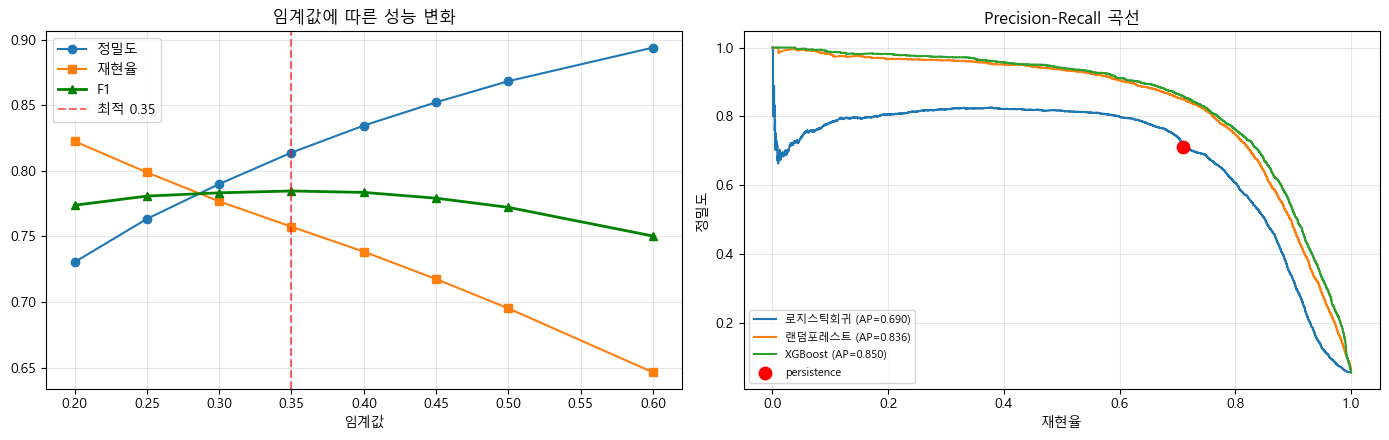

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# 임계값에 따른 트레이드오프
axes[0].plot(thr.임계값, thr.정밀도, marker='o', label='정밀도')
axes[0].plot(thr.임계값, thr.재현율, marker='s', label='재현율')
axes[0].plot(thr.임계값, thr.F1, marker='^', label='F1', lw=2, color='green')
axes[0].axvline(best_t, color='red', ls='--', alpha=.6, label=f'최적 {best_t}')
axes[0].set_xlabel('임계값'); axes[0].set_title('임계값에 따른 성능 변화')
axes[0].legend(); axes[0].grid(alpha=.3)

# PR 곡선
for name, p in probas.items():
    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rc, pr, label=f'{name} (AP={average_precision_score(y_test,p):.3f})')
axes[1].scatter(recall_score(y_test, pred_base), precision_score(y_test, pred_base),
                color='red', s=80, zorder=5, label='persistence')
axes[1].set_xlabel('재현율'); axes[1].set_ylabel('정밀도')
axes[1].set_title('Precision-Recall 곡선'); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

> **임계값 선택은 목적에 달렸다:**
>
> - **0.25 (재현율 0.80):** 놓치는 혼잡을 줄이고 싶을 때. 헛경보는 늘어난다.
> - **0.35 (F1 최대):** 균형점. **본 프로젝트 채택**
> - **0.60 (정밀도 0.90):** 경보의 신뢰도가 중요할 때. 놓치는 혼잡이 늘어난다.
>
> 이런 조정은 **회귀의 R²로는 불가능한 대화**다. 분류로 전환한 실질적 이득이다.

---
## 7. 최종 모델 상세 평가

In [10]:
FINAL_T = float(best_t)
pred_final = (p_best >= FINAL_T).astype(int)

cm = confusion_matrix(y_test, pred_final)
tn, fp, fn, tp = cm.ravel()

print('=== 혼동행렬 (XGBoost, 임계값 %.2f) ===' % FINAL_T)
display(pd.DataFrame(cm,
                     index=['실제 정상', '실제 혼잡'],
                     columns=['예측 정상', '예측 혼잡']))

print(f'''
정확히 잡은 혼잡 (TP): {tp:,}건
놓친 혼잡     (FN): {fn:,}건  → 실제 혼잡의 {100*fn/(tp+fn):.1f}%
헛경보        (FP): {fp:,}건  → 경보 중 {100*fp/(tp+fp):.1f}%
정상 정확 판정 (TN): {tn:,}건
''')

=== 혼동행렬 (XGBoost, 임계값 0.35) ===


,예측 정상,예측 혼잡
실제 정상,97439,1002
실제 혼잡,1404,4384



정확히 잡은 혼잡 (TP): 4,384건
놓친 혼잡     (FN): 1,404건  → 실제 혼잡의 24.3%
헛경보        (FP): 1,002건  → 경보 중 18.6%
정상 정확 판정 (TN): 97,439건



### 7-1. 시간대별 예측 성능

모델이 **언제 잘 맞히고 언제 취약한지** 확인한다.

,시,실제혼잡률(%),재현율,정밀도
0,0,3.2,0.206,0.378
1,1,2.6,0.318,0.686
2,2,3.0,0.270,0.694
3,3,2.5,0.262,0.692
4,4,1.9,0.150,0.429
5,5,1.8,0.385,0.312
6,6,3.2,0.629,0.571
7,7,4.9,0.737,0.734
8,8,5.3,0.919,0.841
9,9,5.6,0.943,0.883


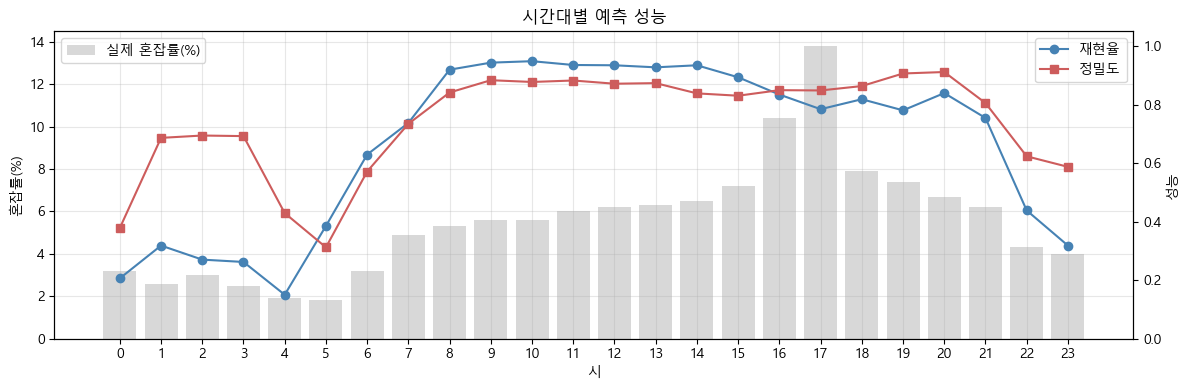

In [11]:
te = test.copy()
te['예측'] = pred_final

hourly = te.groupby('시').apply(lambda x: pd.Series({
    '실제혼잡률(%)': round(100*x.타깃.mean(), 1),
    '재현율': round(recall_score(x.타깃, x.예측, zero_division=0), 3),
    '정밀도': round(precision_score(x.타깃, x.예측, zero_division=0), 3),
})).reset_index()
display(hourly)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly.시, hourly['실제혼잡률(%)'], alpha=.3, color='gray', label='실제 혼잡률(%)')
ax2 = ax.twinx()
ax2.plot(hourly.시, hourly.재현율, marker='o', color='steelblue', label='재현율')
ax2.plot(hourly.시, hourly.정밀도, marker='s', color='indianred', label='정밀도')
ax.set_xlabel('시'); ax.set_ylabel('혼잡률(%)'); ax2.set_ylabel('성능'); ax2.set_ylim(0, 1.05)
ax.set_title('시간대별 예측 성능'); ax.set_xticks(range(24))
ax.legend(loc='upper left'); ax2.legend(loc='upper right'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 7-2. 구간별 예측 성능

In [12]:
seg_perf = te.groupby(['교차로','접근로','이동류'], observed=True).apply(lambda x: pd.Series({
    '표본': len(x),
    '실제혼잡률(%)': round(100*x.타깃.mean(), 1),
    '재현율': round(recall_score(x.타깃, x.예측, zero_division=0), 3),
    '정밀도': round(precision_score(x.타깃, x.예측, zero_division=0), 3),
})).reset_index()

print('=== 혼잡이 실제로 발생하는 구간의 예측 성능 ===')
display(seg_perf[seg_perf['실제혼잡률(%)'] >= 5].sort_values('실제혼잡률(%)', ascending=False))

=== 혼잡이 실제로 발생하는 구간의 예측 성능 ===


,교차로,접근로,이동류,표본,실제혼잡률(%),재현율,정밀도
12,미금역사거리,까치마을사거리 방면,우회전,1992.0,64.6,0.936,0.800
18,미금역사거리,정자일로 방면,우회전,3756.0,62.6,0.931,0.883
29,오리삼거리,오리역 방면,직진,3756.0,16.5,0.881,0.801
28,오리삼거리,오리역 방면,좌회전,2965.0,9.6,0.229,0.714
14,미금역사거리,까치마을사거리 방면,직진,1944.0,9.3,0.796,0.754
26,오리삼거리,오리교1사거리 방면,우회전,3621.0,6.2,0.253,0.445


---
## 8. 저장

In [13]:
import pickle

model_dir = BASE / 'models'
model_dir.mkdir(exist_ok=True)

with open(model_dir / 'xgb_congestion.pkl', 'wb') as f:
    pickle.dump({'model': xgb, 'features': FEATS, 'threshold': FINAL_T}, f)

res.to_csv(PROC / 'model_comparison.csv', index=False, encoding='utf-8-sig')
te[['교차로','접근로','이동류','CollectedDate','타깃','예측']].to_parquet(
    PROC / 'predictions.parquet', index=False)

print(f'모델 저장: {model_dir / "xgb_congestion.pkl"}')
print(f'성능 비교표: {PROC / "model_comparison.csv"}')
print(f'예측 결과: {PROC / "predictions.parquet"}')

모델 저장: C:\Users\chpar\Exercise_CP\work\파란학기 응용\models\xgb_congestion.pkl
성능 비교표: C:\Users\chpar\Exercise_CP\work\파란학기 응용\data\processed\model_comparison.csv
예측 결과: C:\Users\chpar\Exercise_CP\work\파란학기 응용\data\processed\predictions.parquet


---
# 5단계 완료

### 성능 요약

| 모델 | 정밀도 | 재현율 | F1 | 베이스라인 대비 |
|---|---|---|---|---|
| persistence (베이스라인) | 0.711 | 0.710 | 0.710 | — |
| 로지스틱 회귀 | 0.389 | 0.884 | 0.540 | **-24%** |
| 랜덤포레스트 | 0.874 | 0.665 | 0.756 | +6.4% |
| **XGBoost (임계값 0.35)** | **0.815** | **0.759** | **0.786** | **+10.6%** |

### 이 단계에서 지킨 원칙

1. **데이터 누수 차단** — 모든 피처가 예측 시점 이전 정보만 참조.
   이동평균도 `shift(1)`을 먼저 적용해 현재 값이 자기 평균에 포함되지 않게 했다.
2. **결측 구간 처리** — 다음 관측이 정확히 1시간 후가 아니면 타깃을 무효화해,
   센서 공백을 건너뛴 잘못된 학습을 방지했다.
3. **시간 순서 분할** — 앞 17개월 학습, 뒤 5개월 검증.
4. **정확도를 쓰지 않음** — "항상 정상"만 답해도 94.5%가 나오는 함정을 실증했다.
5. **베이스라인 대비 평가** — 절대 성능이 아니라 **개선률**로 말한다.

### 핵심 발견

**로지스틱 회귀가 베이스라인보다 나빴다(-24%).**
재현율 0.88로 혼잡은 잘 잡았지만 정밀도 0.39로 헛경보가 과도했다.
"복잡한 모델이 항상 낫다"는 통념이 틀릴 수 있음을 보여주며,
**베이스라인 없이는 이를 알 수 없었다.**

### 포트폴리오 서술용 메시지

> "이전 프로젝트에서 R² 0.99가 나왔지만 실제값을 입력으로 쓴 부풀려진 수치였다.
> 이번에는 모든 피처를 예측 시점 이전 정보로 제한하고, 단순 기준선을 먼저 만들었다.
> 최종 모델은 기준선 대비 F1을 **10.6% 개선**했고,
> 이 수치는 '얼마나 정확한가'가 아니라 **'단순한 방법보다 얼마나 나은가'**를 의미한다."

---

### 다음 단계
**6단계 — 변수 중요도 및 원인 해석:** 무엇이 혼잡을 예고하는지, 교차로 간 연쇄 효과가 있는지 분석한다.